# Simulation of an observation of a kilonova + an orphan afterglow light curve by Rubin LSST
## (Example of the 170817 event)

(see Matteo and Riccardo's paper: arXiv:2309.03000v1)

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import numpy as np
import scipy
import os
import afterglowpy as grb

from matplotlib.lines import Line2D
from astropy.time import Time, TimeDelta
from astropy.coordinates import SkyCoord
from astropy import units as u

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Import the primary photometry classes from rubin_sim.photUtils
from rubin_sim.data import get_baseline
import rubin_sim.photUtils.Bandpass as Bandpass
import rubin_sim.photUtils.Sed as Sed
import rubin_sim.photUtils.PhotometricParameters as PhotometricParameters
from rubin_sim.photUtils import calcMagError_m5

In [4]:
from orphans.tools import flux_to_mag, mag_to_flux, time_coord
from orphans.grb_interface import make_grb_spectrum
from orphans.plotting_lc import plot_simulation

In [5]:
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

## Open kilonova theoretical light curves

Kilonova lights curves are computed with the POSSIS code (https://github.com/mbulla/kilonova_models) but are not computed for LSST filters so other similar filters are chosen.
The magnitudes are in absolute magnitudes. To convert in apparent magnitudes at another distance:
$$ m = M + 5 \times (log_{10}(d_{L, pc}) - 1) $$
With $m$ the apparent magnitude et $M$ the absolute magnitude. In this notebook, $d_L$ is set to 40 Mpc (z = 0.0099) corresponding to the 170817 event distance.

The model class used here is the one from Dietrich et al. (2020) (https://arxiv.org/abs/2002.11355) for NS-NS mergers that provide the case of a "Red+Blue" kilonova with also a polar lanthanide-free component. The light curves are a function of three fundamental parameters: the mass of the dynamical ejecta $M_{dyn}$, the mass of the disk wind ejecta $M_{dw}$, and the half-opening angle of the lanthanide-rich component $\Phi$ (0° is view edge-on). $\theta$ is the observer angle (0° is view face-on).

In [6]:
file = '/home/masson/kilonova_models/lcs_bns_m2_2comp/nph1.0e+06_mej0.040_phi30_theta25.84_dMpc0.dat'
#file = '/home/masson/kilonova_models/lcs/nph1.0e+06_mejdyn0.001_mejwind0.010_phi15_theta25.84_dMpc0.dat'
df_kn = pd.read_table(file, sep=' ', header=0, usecols=[0, 1, 2, 3, 4, 5, 6],
                    names=['t[days]', 'sdss::u', 'sdss::g', 'sdss::r', 'sdss::i', 'sdss::z', 'swope2::y'])
df_kn

,t[days],sdss::u,sdss::g,sdss::r,sdss::i,sdss::z,swope2::y
0,0.1,-11.185,-12.277,-12.754,-12.759,-12.106,-12.219
1,0.3,-14.483,-15.177,-14.977,-15.245,-14.814,-13.974
2,0.5,-14.814,-15.802,-16.250,-16.018,-15.633,-15.062
3,0.7,-14.851,-15.951,-16.563,-16.541,-15.967,-15.683
4,0.9,-14.798,-15.922,-16.581,-16.528,-16.248,-16.052
...,...,...,...,...,...,...,...
95,19.1,-0.423,-4.474,-6.856,-7.826,-8.511,-8.809
96,19.3,-0.279,-4.269,-6.964,-7.655,-8.285,-8.754
97,19.5,-0.267,-3.910,-6.688,-7.483,-8.215,-8.785
98,19.7,-0.044,-3.549,-6.030,-7.412,-7.902,-8.464


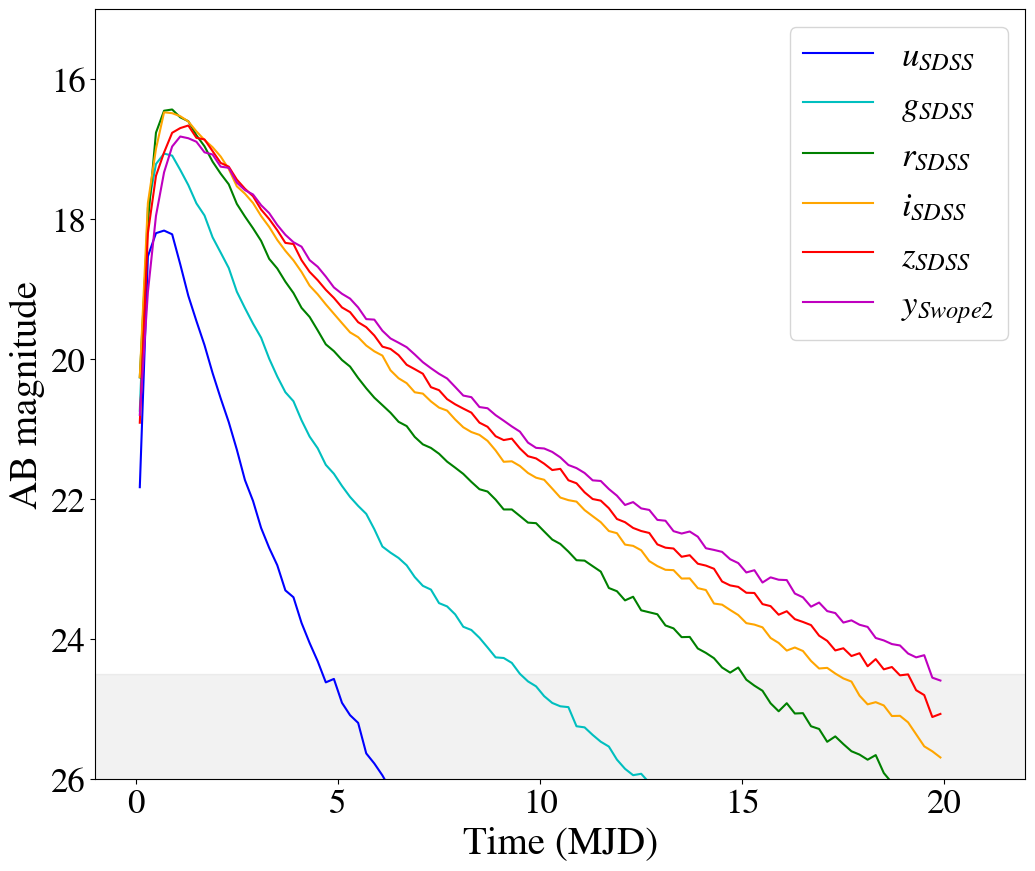

In [9]:
plt.rcParams.update({'font.size': 25})
plt.figure(figsize=(12,10))

filters = ['sdss::u', 'sdss::g', 'sdss::r', 'sdss::i', 'sdss::z', 'swope2::y']
filters_labels = ['$u_{SDSS}$', '$g_{SDSS}$', '$r_{SDSS}$', '$i_{SDSS}$', '$z_{SDSS}$', '$y_{Swope2}$']
colors = ['b', 'c', 'g', 'orange', 'r', 'm']

for f, c, l in zip(filters, colors, filters_labels):
    plt.plot(df_kn['t[days]'], df_kn[f]+5*(np.log10(40e6)-1), color=c, label=l)        
        
plt.fill_between([-1e2, 1e3], 24.5, 31., color='k', alpha=0.05)
plt.gca().invert_yaxis()
plt.xlabel('Time (MJD)', fontsize=28)
plt.ylabel('AB magnitude', fontsize=28)
#plt.xscale('log')
plt.xlim(-1, 22)
plt.ylim(26, 15)
plt.legend()

#plt.savefig('../figures/at2017gfo_lc_possis.pdf', format="pdf", bbox_inches="tight", transparent=True)

## Simulate the observation of a AT2017gfo + GRB170817A afterglow by Rubin LSST
### Define some useful functions...

In [120]:
file = '/home/masson/kilonova_models/lcs_bns_m2_2comp/nph1.0e+06_mej0.040_phi30_theta25.84_dMpc0.dat'
df_kn = pd.read_table(file, sep=' ', header=0, usecols=[0, 1, 2, 3, 4, 5, 6],
                    names=['t[days]', 'sdss::u', 'sdss::g', 'sdss::r', 'sdss::i', 'sdss::z', 'swope2::y'])

In [121]:
def obs_time(df_sky, grb_time):
    """ Compute the observation time in the GRB time frame, i.e. from GRB T_0
    """

    obs_times_frame = df_sky['observationStartMJD'] - T0.mjd
    time_bins = obs_times_frame[obs_times_frame > 0]
    
    return time_bins

    

def compute_mags_kn(obs_id, wls, mag, obs_t):
    """ Save the observed magnitude at the time of the detection in a DataFrame
    """
    
    new_kn_sed = Sed()
    new_kn_sed.wavelen = np.array(wls)
    # calculate expected AB magnitudes. 
    new_kn_mags = {}
    for i, f in enumerate(filterlist):
        new_kn_mags[f] = mag[i]
    new_kn_mags['obs_time'] = obs_t
    
    # make a dataframe just to get a nice output cell.
    return pd.DataFrame(new_kn_mags, index=[obs_id])


def compute_mags_grb(i, wls, fnus, obs_t, f, lsst):
    """ Compute the observed magnitude at the time of the detection and save it in a DataFrame
    """
    
    new_grb_sed = Sed()
    new_grb_sed.wavelen = np.array(wls)
    new_grb_sed.fnu = np.array(fnus)
    # convert fnu to flambda
    new_grb_sed.fnuToflambda()
    # Calculate expected AB magnitudes. 
    new_grb_mags = {}
    new_grb_mags[str(f)] = new_grb_sed.calcMag(lsst[f])
    # time is one column
    new_grb_mags['obs_time'] = obs_t
    # Make a dataframe just to get a nice output cell.
    return pd.DataFrame(new_grb_mags, index=[i])


def df_obs_kn(df_sky, time_bins, lsst):
    """ Compute magnitudes in each filter at the observation time
    """
    
    # compute spectra at observation time bins
    mag = dict()
    for obs_id, obs_t in time_bins.to_dict().items():
    
        # wavelengths of the filters used to compute KN light curves
        wl_full_band = [354., 475., 622., 763., 905., 1034.6]
    
        # interpolation of the flux
        mag_int = []
        for f in filt_kn:
            interpolation = scipy.interpolate.interp1d(df_kn['t[days]'], 
                                                       df_kn[f].apply(lambda x: x+5*(np.log10(40e6)-1))) 
            mag_int.append(interpolation(obs_t))
        
        mag[obs_id] = mag_int
        
    # compute magnitudes
    obs_list = []
    for obs_id, m in mag.items():
        
        obs_t = time_bins[obs_id]
        df = compute_mags_kn(obs_id, wl_full_band, m, obs_t)
        obs_list.append(df)
        
    return obs_list


def df_obs_grb(config, df_sky, time_bins, lsst):

    """ Compute magnitudes in each filter at the observation time
    """
    
    Z = config
    Fnu_Jy = dict()
    for obs_id, obs_t in time_bins.to_dict().items():
        wl_full_band, freq_full_band, t, Fnu_Jy[obs_id] = make_grb_spectrum(jetType=Z['jetType'], 
                                                                            specType=Z['specType'], 
                                                                            E0=Z['E0'], z=Z['z'], 
                                                                            n0=Z['n0'], 
                                                                            thetaObs=Z['thetaObs'], 
                                                                            thetaCore=Z['thetaCore'], 
                                                                            thetaWing=Z['thetaWing'], 
                                                                            t=obs_t * grb.day2sec)
    
    obs_list = list()
    for obs_id, fnu_val in Fnu_Jy.items():
        obs_t = time_bins[obs_id]
        filt = df_sky[df_sky['observationId']==obs_id]['filter']
        df = compute_mags_grb(obs_id, wl_full_band, fnu_val, obs_t, filt.values[0], lsst)
        obs_list.append(df)
        
    return obs_list


def real_obs(obs_df, df_sky, time_bins, grb_time, lsst):
    """ Keep only "real" observations for the right filter
    """

    x_times = []
    y_mags = []
    z_colors = []
    mags_lim = []
    mags_err = []

    for obs_id, obs in obs_df.iterrows():

        filt = df_sky[df_sky['observationId'] == obs_id]['filter']
        lim = df_sky[df_sky['observationId'] == obs_id]['fiveSigmaDepth']
        exptime = df_sky[df_sky['observationId'] == obs_id]['visitExposureTime']
        nexp = df_sky[df_sky['observationId'] == obs_id]['numExposures']
        phot_params = PhotometricParameters(exptime=exptime, nexp=nexp, readnoise=None)
        obs_t = time_bins[obs_id]

        x_times.append(obs_t + grb_time.mjd)
        y_mags.append(obs[filt].values[0])
        z_colors.append(filtercolors[filt.values[0]])
        mags_lim.append(lim.values[0])
        mags_err.append(calcMagError_m5(magnitude=obs[filt].values[0], bandpass=lsst[filt.values[0]], 
                                        m5=lim.values[0], photParams=phot_params))

    return x_times, y_mags, z_colors, mags_lim, mags_err

### Compute...

In [126]:
# GRB configuration of GRB170817A
config = {'jetType': grb.jet.PowerLaw,  # Jet Type
          'specType': 0,  # Emission Spectrum
          'b': 4,  # Power Law index
          'thetaObs': 0.3,  # Viewing angle in radians
          'E0': 1e53,  # Isotropic-equivalent energy in erg
          'thetaWing': 0.24,  # Truncation angle in radians
          'thetaCore': 0.05,  # Half-opening angle in radians
          'n0': 0.1,  # Circumburst density in cm^{-3}
          'p': 2.2,  # Electron energy distribution index
          'epsilon_e': 0.1,  # epsilon_e
          'epsilon_B': 0.01,  # epsilon_B
          'xi_N': 1.,  # Fraction of electrons accelerated
          'd_L': 1.3612767382948761e+26,  # Luminosity distance in cm
          'z': 0.0099}  # Redshift

In [127]:
baseline_db = get_baseline()
conn = sqlite3.connect(baseline_db)
df = pd.read_sql('select * from observations;', conn)
conn.close()

fdir = '/home/masson/rubin_sim_data'
fdir = os.path.join(fdir, 'throughputs', 'baseline')

# read the throughput curves
filterlist = ['u', 'g', 'r', 'i', 'z', 'y']
filtercolors = {'u': 'b', 'g': 'c', 'r': 'g', 'i': 'orange', 'z': 'r', 'y': 'm'}
filt_kn = ['sdss::u', 'sdss::g', 'sdss::r', 'sdss::i', 'sdss::z', 'swope2::y']


lsst = {}
for f in filterlist:
    lsst[f] = Bandpass()
    lsst[f].readThroughput(os.path.join(fdir, f'total_{f}.dat'))
    

# time in mjd and ra/dec coordinates of the KN
#T0, coord = time_coord()
T0 = Time(62114.62630306261, format='mjd', scale='utc')
coord = SkyCoord(16.69624316*u.degree, -30.11396906*u.degree, frame='icrs')



#------------ KN PSEUDO-OBSERVATION -------------------------------------------------------------------------#


# dictionary containing all the KN information
LC_KN = {'config': 'mej0.040_phi30_theta25.84',  # KN config
         'T0': T0,  # KN observation date
         'coord': coord,  # KN ra/dec coordinates
         'time': [],  # time of each detection
         'mags': [],  # magnitude of the detection
         'filt': [],  # filter used at the moment of the detection
         'mags_lim': [],  # limiting magnitude of the detection at the observation time
         'mags_err': []}   # error on the magnitude

# observe t_before days before and t_after days after
t_before = TimeDelta(20, format='jd')
t_after = TimeDelta(20, format='jd')
obs_start = T0 - t_before
obs_end = T0 + t_after

# get time span
df_time = df[(df['observationStartMJD'] > obs_start.mjd) & (df['observationStartMJD'] < obs_end.mjd)]

# angular separation with SkyCoord.separation
# Rubin FOV is 47 square degree for a 3.5-degree diameter, hence 1.7 deg separation radius.
df_time['Separation'] = SkyCoord(df_time['fieldRA'], df_time['fieldDec'], unit="deg").separation(coord).degree
df_sky = df_time[df_time['Separation'] < 1.7]

time_bins = obs_time(df_sky, T0)

obs_list = df_obs_kn(df_sky, time_bins, lsst)

# if there is no observation, let's give up
if len(obs_list) == 0:
    print('No KN observation')

# else, let's simulate the observation
else:
    obs_df = pd.concat(obs_list)
    obs_df['observationId'] = df_sky['observationId']
            
    x_times, y_mags, z_colors, mags_lim, mags_err = real_obs(obs_df, df_sky, time_bins, T0, lsst)

    LC_KN['mags'] = y_mags
    LC_KN['T0'] = T0.isot
    LC_KN['coord'] = coord.to_string('hmsdms')
    LC_KN['time'] = x_times
    LC_KN['filt'] = z_colors
    LC_KN['mags_lim'] = mags_lim
    LC_KN['mags_err'] = [np.array(mags_err)[:, 0, 0]]



#------------ GRB PSEUDO-OBSERVATION ------------------------------------------------------------------------#


# dictionary containing all the GRB information
LC_GRB = {'config': config,  # GRB config
          'T0': T0,  # GRB observation date
          'coord': coord,  # GRB ra/dec coordinates
          'time': [],  # time of each detection
          'mags': [],  # magnitude of the detection
          'filt': [],  # filter used at the moment of the detection
          'mags_lim': [],  # limiting magnitude of the detection at the observation time
          'mags_err': []}   # error on the magnitude

# observe t_before days before and t_after days after
t_before = TimeDelta(20, format='jd')
t_after = TimeDelta(365, format='jd')
obs_start = T0 - t_before
obs_end = T0 + t_after

# get time span
df_time = df[(df['observationStartMJD'] > obs_start.mjd) & (df['observationStartMJD'] < obs_end.mjd)]

# angular separation with SkyCoord.separation
# Rubin FOV is 47 square degree for a 3.5-degree diameter, hence 1.7 deg separation radius.
df_time['Separation'] = SkyCoord(df_time['fieldRA'], df_time['fieldDec'], unit="deg").separation(coord).degree
df_sky = df_time[df_time['Separation'] < 1.7]
time_bins = obs_time(df_sky, T0)

obs_list = df_obs_grb(LC_GRB['config'], df_sky, time_bins, lsst)

# if there is no observation, let's give up
if len(obs_list) == 0:
    print('No GRB afterglow observation')

# else, let's simulate the observations 
else:
    
    obs_df = pd.concat(obs_list)
    obs_df['observationId'] = df_sky['observationId']
    
    x_times, y_mags, z_colors, mags_lim, mags_err = real_obs(obs_df, df_sky, time_bins, T0, lsst)
    
    LC_GRB['mags'] = y_mags
    LC_GRB['T0'] = T0.isot
    LC_GRB['coord'] = coord.to_string('hmsdms')
    LC_GRB['time'] = x_times
    LC_GRB['filt'] = z_colors
    LC_GRB['mags_lim'] = mags_lim
    LC_GRB['mags_err'] = [np.array(mags_err)[:, 0, 0]]

### ... And plot!

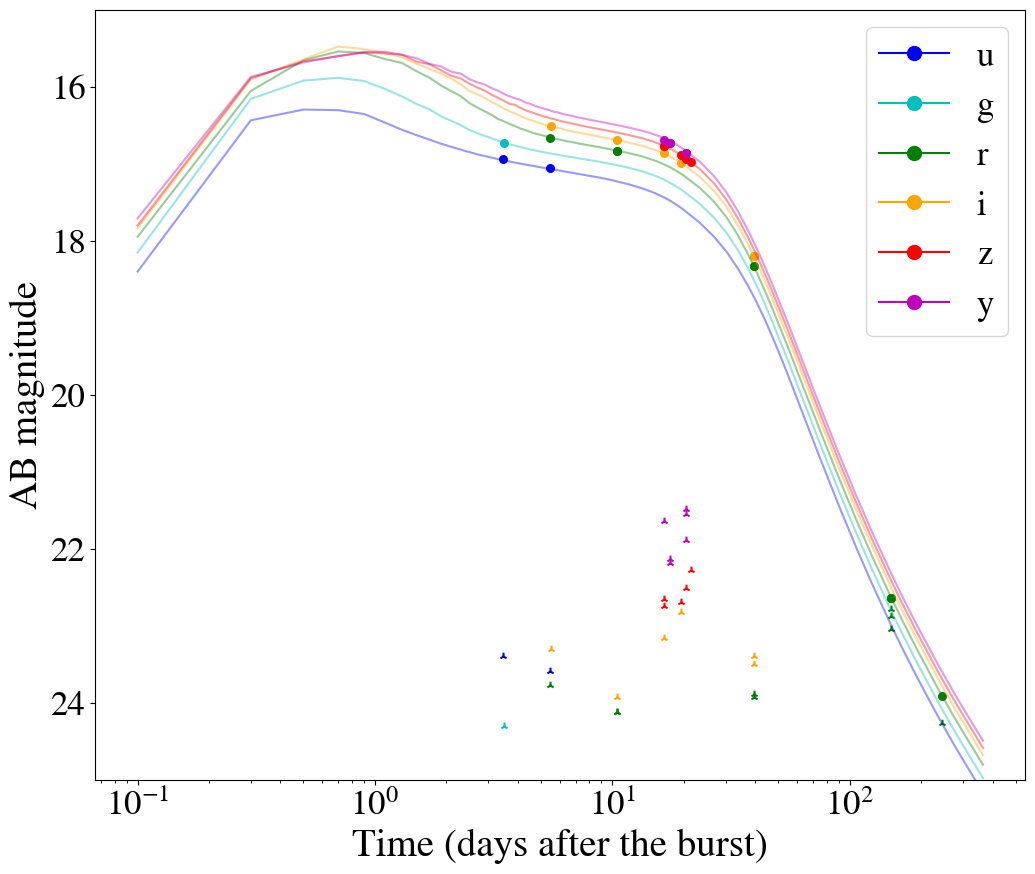

In [130]:
plt.rcParams.update({'font.size': 25})
plt.figure(figsize=(12,10))

colors = ['b', 'c', 'g', 'orange', 'r', 'm']
filt_kn = ['sdss::u', 'sdss::g', 'sdss::r', 'sdss::i', 'sdss::z', 'swope2::y']
nu_lsst = [840336134453781.4, 629326620516047.8, 482703137570394.2, 397614314115308.1, 344530577088716.56, 
             298760145396604.1] 

x_times_kn = LC_KN['time']
y_mags_kn = LC_KN['mags']
z_colors_kn = LC_KN['filt']
mags_err_kn = LC_KN['mags_err'][0]
mags_lim_kn = LC_KN['mags_lim']
        
x_times_grb = LC_GRB['time']
y_mags_grb = LC_GRB['mags']
z_colors_grb = LC_GRB['filt']
mags_err_grb = LC_GRB['mags_err'][0]
mags_lim_grb = LC_GRB['mags_lim']


# calculate the total flux (combination the kilonova and the GRB detections)
# this should be done BEFORE the pseudo-observation to compute correctly the error on the magnitude
y_mags = []
for i in range(len(x_times_grb)):
    if i <= (len(x_times_kn)-1):
        y_mags.append(flux_to_mag(mag_to_flux(y_mags_kn[i]) + mag_to_flux(y_mags_grb[i])))
    else:
        y_mags.append(y_mags_grb[i])
        
for x, y, z, e, m in zip(x_times_grb, y_mags, z_colors_grb, mags_err_grb, mags_lim_grb):
    if y<m:
        plt.scatter(x-Time(T0).mjd, y, c=z, s=30)
        #plt.errorbar(x, y, e, c=z)
        plt.scatter(x-Time(T0).mjd, m, c=z, marker='2', s=30)
        
        
# plot KN pseudo observed light curve
#for x, y, z, e, m in zip(x_times_kn, y_mags_kn, z_colors_kn, mags_err_kn, mags_lim_kn):
#    if y<m:
#        plt.scatter(x, y, c=z, s=100)
#        plt.errorbar(x, y, e, c=z)
#        plt.scatter(x, m, c=z, marker='2', s=100)

# plot GRB afterglow pseudo observed light curve
#for x, y, z, e, m in zip(x_times_grb, y_mags_grb, z_colors_grb, mags_err_grb, mags_lim_grb):
#    if y<m:
#        plt.scatter(x, y, c=z, s=70)
#        plt.errorbar(x, y, e, c=z)
#        plt.scatter(x, m, c=z, marker='2', s=100)

file = '/home/masson/kilonova_models/lcs_bns_m2_2comp/nph1.0e+06_mej0.040_phi30_theta25.84_dMpc0.dat'
df_kn = pd.read_table(file, sep=' ', header=0, usecols=[0, 1, 2, 3, 4, 5, 6],
                    names=['t[days]', 'sdss::u', 'sdss::g', 'sdss::r', 'sdss::i', 'sdss::z', 'swope2::y'])

t = np.geomspace(min(df_kn['t[days]']), max(LC_GRB['time'])-Time(LC_GRB['T0']).mjd, 300)
t_late = np.linspace(max(df_kn['t[days]']), max(df_kn['t[days]'])+345, 100)
time_tot = np.concatenate((df_kn['t[days]'], t_late))

Ftot = [[]]*6

for i, (nu, nu_kn)  in enumerate(zip(nu_lsst, filters)):
    
    Fnu_grb_early = grb.fluxDensity(df_kn['t[days]'] * grb.day2sec, nu, **config)    # flux in mJy
    Fnu_grb_late = grb.fluxDensity(t_late * grb.day2sec, nu, **config)
    Fnu_kn = mag_to_flux(df_kn[nu_kn]+5*(np.log10(40e6)-1))
    Ftot_early = Fnu_grb_early + Fnu_kn
    Ftot[i] = np.concatenate((Ftot_early, Fnu_grb_late))
    

for i, c in enumerate(colors):
    plt.plot(time_tot, flux_to_mag(np.array(Ftot[i])), color=c, alpha=0.4)
        
        
plt.gca().invert_yaxis()
plt.xlabel('Time (days after the burst)', fontsize=28)
plt.ylabel('AB magnitude', fontsize=28)

legend_elements_2 = []
for filt in filterlist:
    fcolor = filtercolors[filt]
    legend_elements_2.append(Line2D([0], [0], marker='o', color=fcolor, label=filt,
                                  markerfacecolor=fcolor, markersize=10))
plt.legend(handles=legend_elements_2)
plt.ylim(25, 15)
plt.xscale('log')
#plt.xlim(62110, 62190)

#plt.savefig('../figures/kn+oa_pseudo_obs_close.pdf', format="pdf", bbox_inches="tight", transparent=True)
plt.show()

### Theoretical light curve for reference

In [12]:
# compute the GBR afterglow theoretical light curve in each LSST filter
config = LC_GRB['config']

t = np.geomspace(min(df_kn['t[days]']), max(LC_GRB['time'])-Time(LC_GRB['T0']).mjd, 300)

mag_grb = [[]]*6

for i, nu in enumerate(nu_lsst):
    
    Fnu = grb.fluxDensity(t * grb.day2sec, nu, **config)    # flux in Jy
    mag_grb[i] = -2.5 * np.log10(Fnu*1.0e-26) - 48.6 

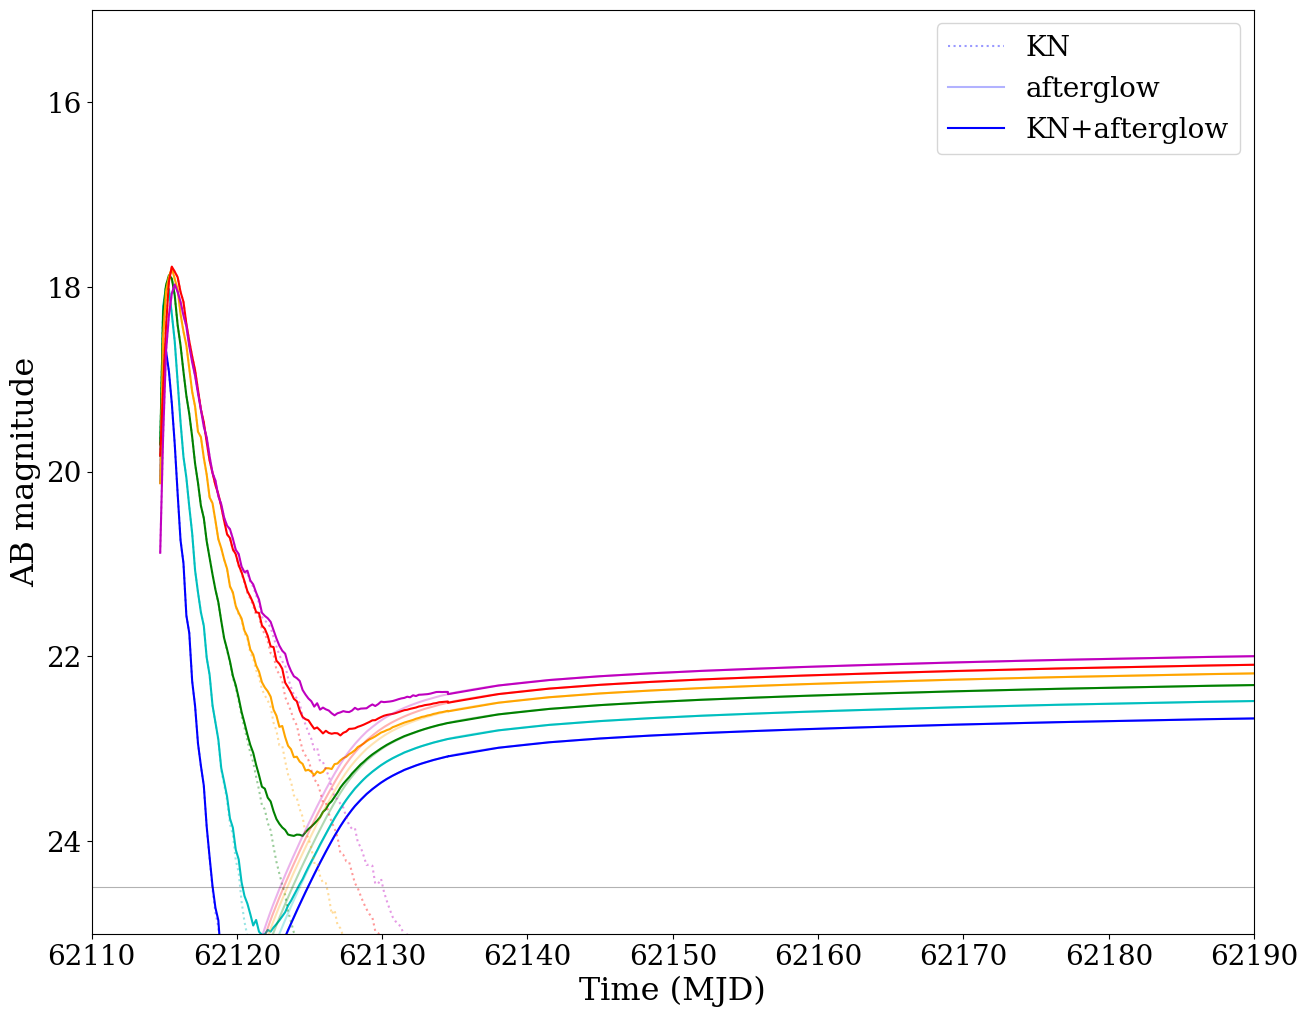

In [14]:
plt.rcParams.update({'font.size': 20})
plt.rcParams['figure.figsize'] = [15, 12]

filters = ['sdss::u', 'sdss::g', 'sdss::r', 'sdss::i', 'sdss::z', 'swope2::y']
colors = ['b', 'c', 'g', 'orange', 'r', 'm']

time_tot = np.concatenate((df_kn['t[days]'], t_late))

for i, (f, c) in enumerate(zip(filters, colors)):
    
    if f == 'sdss::u':
        plt.plot(df_kn['t[days]']+Time(T0).mjd, df_kn[f]+5*(np.log10(40e6)-1), ls=':', color=c, alpha = 0.4, label='KN')
        plt.plot(t+Time(T0).mjd, mag_grb[i], color=c, alpha=0.3, label='afterglow')
        plt.plot(time_tot+Time(T0).mjd, flux_to_mag(np.array(Ftot[i])), color=c, label='KN+afterglow')
        
    else:
        plt.plot(df_kn['t[days]']+Time(T0).mjd, df_kn[f]+5*(np.log10(40e6)-1), ls=':', color=c, alpha=0.4)
        plt.plot(t+Time(T0).mjd, mag_grb[i], color=c, alpha = 0.3)
        plt.plot(time_tot+Time(T0).mjd, flux_to_mag(np.array(Ftot[i])), color=c)
        
        
plt.axhline(y=24.5, lw=0.8, color='k', alpha=0.3)
plt.gca().invert_yaxis()
plt.xlabel('Time (MJD)', fontsize=23)
plt.ylabel('AB magnitude', fontsize=23)
plt.xlim(62110, 62190)
plt.ylim(25, 15)
plt.legend()